# Open Domain QA - Negative Sampling with Curriculum Learning

This notebook creates a training dataset with:
- **Negative sampling**: Top-4 contexts (by BM25Plus) excluding the correct answer
- **Difficulty metric**: `difficulty = 1 / bm25plus(question, answer_context)`
- **Random positioning**: Correct context randomly placed among negative samples

In [ ]:
# Install required packages
# Uncomment the line below if packages are not installed
# %pip install -q rank-bm25 numpy pandas tqdm datasets python-mecab-ko

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import random
import numpy as np
from pathlib import Path
from typing import List, Dict, Tuple
from rank_bm25 import BM25Plus
from tqdm import tqdm

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

## 1. Load Training Dataset

In [ ]:
# Define paths
TRAIN_DATA_PATH = '../data/train_dataset/train'
OUTPUT_PATH = '../data/train_dataset/train_negative'

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Load HuggingFace dataset (Arrow format)
from datasets import load_from_disk

print("Loading training dataset from Arrow format...")
dataset = load_from_disk(TRAIN_DATA_PATH)
train_data = list(dataset)  # Convert to list of dicts

print(f"Loaded {len(train_data)} training examples")
print(f"\nDataset columns: {list(dataset.features.keys())}")
print(f"\nFirst example:")
print(f"Question: {train_data[0]['question']}")
print(f"Context (first 200 chars): {train_data[0]['context'][:200]}...")
print(f"Answer: {train_data[0]['answers']['text']}")

Loading training dataset from Arrow format...
Loaded 3952 training examples

Dataset columns: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__']

First example:
Question: 대통령을 포함한 미국의 행정부 견제권을 갖는 국가 기관은?
Context (first 200 chars): 미국 상의원 또는 미국 상원(United States Senate)은 양원제인 미국 의회의 상원이다.\n\n미국 부통령이 상원의장이 된다. 각 주당 2명의 상원의원이 선출되어 100명의 상원의원으로 구성되어 있다. 임기는 6년이며, 2년마다 50개주 중 1/3씩 상원의원을 새로 선출하여 연방에 보낸다.\n\n미국 상원은 미국 하원과는 다르게 미국 대통령을 ...
Answer: ['하원']


## 2. Extract All Contexts for BM25 Index

In [4]:
def extract_contexts(data: List[Dict]) -> Tuple[List[str], Dict[str, int]]:
    """
    Extract all unique contexts from the dataset.
    For HuggingFace datasets with 'context' field.
    """
    contexts = []
    context_to_idx = {}
    
    for item in data:
        ctx = item['context']
        if ctx not in context_to_idx:
            context_to_idx[ctx] = len(contexts)
            contexts.append(ctx)
    
    print(f"Extracted {len(contexts)} unique contexts")
    return contexts, context_to_idx

print("Extracting unique contexts from dataset...")
all_contexts, context_to_idx = extract_contexts(train_data)
print(f"\nSample context:")
print(all_contexts[0][:200] + "..." if len(all_contexts[0]) > 200 else all_contexts[0])

Extracting unique contexts from dataset...
Extracted 3340 unique contexts

Sample context:
미국 상의원 또는 미국 상원(United States Senate)은 양원제인 미국 의회의 상원이다.\n\n미국 부통령이 상원의장이 된다. 각 주당 2명의 상원의원이 선출되어 100명의 상원의원으로 구성되어 있다. 임기는 6년이며, 2년마다 50개주 중 1/3씩 상원의원을 새로 선출하여 연방에 보낸다.\n\n미국 상원은 미국 하원과는 다르게 미국 대통령을 ...


## 3. Build BM25Plus Index

In [5]:
# Using MeCab tokenizer for Korean text
try:
    import mecab
    mecab_tokenizer = mecab.MeCab()
    
    def tokenize(text: str) -> List[str]:
        """Korean tokenization using MeCab morphological analyzer"""
        # MeCab morphs returns list of tokens
        tokens = mecab_tokenizer.morphs(text.lower())
        return tokens
    
    print("✅ Using MeCab tokenizer for Korean text")
    
except ImportError:
    print("⚠️  MeCab not installed. Using simple character-based tokenization.")
    print("   For better results, install python-mecab-ko: pip install python-mecab-ko")
    
    def tokenize(text: str) -> List[str]:
        """Fallback: Character-based tokenization for Korean"""
        import re
        # Remove special characters and split into characters
        text = re.sub(r'[^\w\s]', ' ', text.lower())
        # Split by whitespace and then by character for Korean
        tokens = []
        for word in text.split():
            # Check if word contains Korean characters
            if any('\uac00' <= c <= '\ud7a3' for c in word):
                # Split Korean word into characters
                tokens.extend(list(word))
            else:
                # Keep non-Korean words as is
                tokens.append(word)
        return [t for t in tokens if t.strip()]

# Test tokenization
sample_text = "뮈라가 축출하려한 사람은?"
sample_tokens = tokenize(sample_text)
print(f"\nTest tokenization:")
print(f"Input: {sample_text}")
print(f"Tokens: {sample_tokens}")

print("\nTokenizing contexts for BM25...")
tokenized_contexts = [tokenize(ctx) for ctx in tqdm(all_contexts)]

print("Building BM25Plus index...")
bm25 = BM25Plus(tokenized_contexts)
print("✅ BM25Plus index built successfully!")

✅ Using MeCab tokenizer for Korean text

Test tokenization:
Input: 뮈라가 축출하려한 사람은?
Tokens: ['뮈라', '가', '축출', '하', '려', '한', '사람', '은', '?']

Tokenizing contexts for BM25...


100%|██████████| 3340/3340 [00:24<00:00, 135.27it/s]


Building BM25Plus index...
✅ BM25Plus index built successfully!


## 4. Process Dataset with Negative Sampling

In [6]:
def get_correct_context(item: Dict) -> str:
    """Extract the correct context from a data item - adjust based on your format"""
    # Adjust these keys based on your dataset structure
    if 'context' in item:
        return item['context']
    elif 'positive_ctxs' in item and len(item['positive_ctxs']) > 0:
        return item['positive_ctxs'][0].get('text', item['positive_ctxs'][0].get('passage', ''))
    elif 'answer_context' in item:
        return item['answer_context']
    else:
        raise ValueError(f"Cannot find correct context in item: {list(item.keys())}")

def get_question(item: Dict) -> str:
    """Extract question from a data item - adjust based on your format"""
    if 'question' in item:
        return item['question']
    elif 'query' in item:
        return item['query']
    else:
        raise ValueError(f"Cannot find question in item: {list(item.keys())}")

def calculate_difficulty(question: str, answer_context: str, bm25_model: BM25Plus, 
                        tokenized_contexts: List[List[str]], all_contexts: List[str]) -> float:
    """
    Calculate difficulty metric: difficulty = 1 / bm25plus(question, answer_context)
    Higher BM25 score = easier (lower difficulty)
    Lower BM25 score = harder (higher difficulty)
    """
    tokenized_query = tokenize(question)
    
    # Get BM25 scores for all contexts
    scores = bm25_model.get_scores(tokenized_query)
    
    # Find the score for the answer context
    try:
        answer_idx = all_contexts.index(answer_context)
        answer_score = scores[answer_idx]
    except ValueError:
        # If exact match not found, find the most similar context
        answer_score = max(scores)  # Use max as fallback
    
    # Avoid division by zero
    if answer_score <= 0:
        answer_score = 1e-6
    
    difficulty = 1.0 / answer_score
    return difficulty

def get_negative_samples(question: str, correct_context: str, bm25_model: BM25Plus,
                        all_contexts: List[str], top_k: int = 4) -> List[str]:
    """
    Get top-k contexts (excluding correct answer) as negative samples
    """
    tokenized_query = tokenize(question)
    scores = bm25_model.get_scores(tokenized_query)
    
    # Get indices sorted by score (descending)
    ranked_indices = np.argsort(scores)[::-1]
    
    # Collect top-k excluding the correct context
    negative_samples = []
    for idx in ranked_indices:
        if len(negative_samples) >= top_k:
            break
        if all_contexts[idx] != correct_context:
            negative_samples.append(all_contexts[idx])
    
    return negative_samples

def create_combined_context(correct_context: str, negative_contexts: List[str]) -> Tuple[str, int]:
    """
    Combine correct context with negative contexts, with correct context at random position
    Returns: (combined_context, correct_position)
    """
    all_ctxs = negative_contexts + [correct_context]
    
    # Randomly shuffle
    random.shuffle(all_ctxs)
    
    # Find position of correct context
    correct_position = all_ctxs.index(correct_context)
    
    # Combine contexts with separator
    combined = "\n\n---\n\n".join(all_ctxs)
    
    return combined, correct_position

In [7]:
print("Processing training data with negative sampling...")
processed_data = []

for item in tqdm(train_data):
    try:
        # Extract question and correct context
        question = get_question(item)
        correct_context = get_correct_context(item)
        
        # Calculate difficulty
        difficulty = calculate_difficulty(question, correct_context, bm25, 
                                         tokenized_contexts, all_contexts)
        
        # Get negative samples (top-4 excluding correct answer)
        negative_contexts = get_negative_samples(question, correct_context, bm25, 
                                                all_contexts, top_k=4)
        
        # Combine contexts with random positioning
        combined_context, correct_position = create_combined_context(correct_context, 
                                                                     negative_contexts)
        
        # Create processed item
        processed_item = {
            'question': question,
            'context': combined_context,
            'correct_context': correct_context,
            'correct_position': correct_position,
            'negative_contexts': negative_contexts,
            'difficulty': difficulty,
            'num_contexts': len(negative_contexts) + 1
        }
        
        # Preserve other fields from original data
        for key, value in item.items():
            if key not in processed_item and key not in ['context', 'contexts', 'positive_ctxs']:
                processed_item[key] = value
        
        processed_data.append(processed_item)
        
    except Exception as e:
        print(f"\nError processing item: {e}")
        print(f"Item keys: {list(item.keys())}")
        continue

print(f"\nSuccessfully processed {len(processed_data)} examples")

Processing training data with negative sampling...


100%|██████████| 3952/3952 [03:32<00:00, 18.58it/s]


Successfully processed 3952 examples


In [8]:
# %pip install -q numpy matplotlib

## 5. Analyze Difficulty Distribution

Difficulty Statistics:
  Min: 0.0049
  Max: 0.0650
  Mean: 0.0169
  Median: 0.0158
  Std: 0.0063


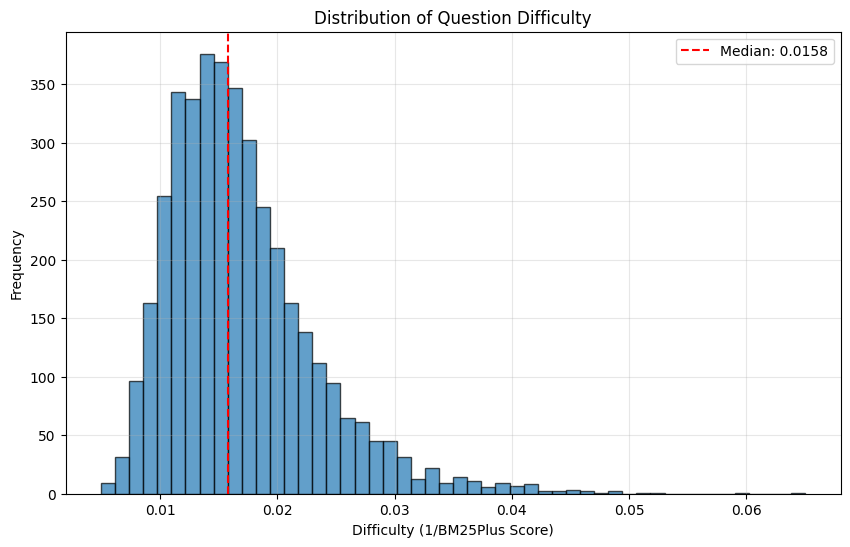


EASIEST EXAMPLE (Lowest Difficulty):
Difficulty: 0.0049
Question: 키에스콤파스에 따르면 동성결혼 분야에서 리쿠드당, 베이테이누당과 정반대 성향을 보이는 이스라엘 정당은?
Correct Position: 0 / 5

HARDEST EXAMPLE (Highest Difficulty):
Difficulty: 0.0650
Question: 이브라임 퍄샤는 누구의 자식인가?
Correct Position: 1 / 5


In [9]:
import matplotlib.pyplot as plt

difficulties = [item['difficulty'] for item in processed_data]

print(f"Difficulty Statistics:")
print(f"  Min: {min(difficulties):.4f}")
print(f"  Max: {max(difficulties):.4f}")
print(f"  Mean: {np.mean(difficulties):.4f}")
print(f"  Median: {np.median(difficulties):.4f}")
print(f"  Std: {np.std(difficulties):.4f}")

# Plot difficulty distribution
plt.figure(figsize=(10, 6))
plt.hist(difficulties, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Difficulty (1/BM25Plus Score)')
plt.ylabel('Frequency')
plt.title('Distribution of Question Difficulty')
plt.axvline(np.median(difficulties), color='r', linestyle='--', label=f'Median: {np.median(difficulties):.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Show examples from different difficulty levels
sorted_data = sorted(processed_data, key=lambda x: x['difficulty'])

print("\n" + "="*80)
print("EASIEST EXAMPLE (Lowest Difficulty):")
print("="*80)
easy = sorted_data[0]
print(f"Difficulty: {easy['difficulty']:.4f}")
print(f"Question: {easy['question']}")
print(f"Correct Position: {easy['correct_position']} / {easy['num_contexts']}")

print("\n" + "="*80)
print("HARDEST EXAMPLE (Highest Difficulty):")
print("="*80)
hard = sorted_data[-1]
print(f"Difficulty: {hard['difficulty']:.4f}")
print(f"Question: {hard['question']}")
print(f"Correct Position: {hard['correct_position']} / {hard['num_contexts']}")

## 6. Save Processed Dataset

In [10]:
# Sort by difficulty for curriculum learning
processed_data_sorted = sorted(processed_data, key=lambda x: x['difficulty'])

print(f"Total examples to save: {len(processed_data_sorted)}")

# Convert to HuggingFace Dataset and save as Arrow format
from datasets import Dataset, Features, Value, Sequence

# Define the schema
features = Features({
    'id': Value('string'),
    'title': Value('string'),
    'question': Value('string'),
    'context': Value('string'),  # Combined context (5 contexts)
    'answers': {
        'text': Sequence(Value('string')),
        'answer_start': Sequence(Value('int64'))
    },
    'document_id': Value('int64'),
    '__index_level_0__': Value('int64'),
    'correct_context': Value('string'),  # Original correct context
    'correct_position': Value('int64'),  # Position of correct context (0-4)
    'negative_contexts': Sequence(Value('string')),  # List of 4 negative contexts
    'difficulty': Value('float64'),
    'num_contexts': Value('int64')
})

# Create HuggingFace Dataset
processed_dataset = Dataset.from_list(processed_data_sorted, features=features)

# Save as Arrow format (same as input format)
processed_dataset.save_to_disk(OUTPUT_PATH)

print(f"\n✅ Saved processed dataset to: {OUTPUT_PATH}")
print(f"   - data-00000-of-00001.arrow (or dataset.arrow)")
print(f"   - dataset_info.json")
print(f"   - state.json")

# Also save as JSON and JSONL for convenience
output_file = os.path.join(OUTPUT_PATH, 'train_with_negatives.json')
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(processed_data_sorted, f, ensure_ascii=False, indent=2)

output_file_jsonl = os.path.join(OUTPUT_PATH, 'train_with_negatives.jsonl')
with open(output_file_jsonl, 'w', encoding='utf-8') as f:
    for item in processed_data_sorted:
        f.write(json.dumps(item, ensure_ascii=False) + '\n')

print(f"\n✅ Additional formats saved:")
print(f"   - {output_file}")
print(f"   - {output_file_jsonl}")

# Save metadata
metadata = {
    'total_examples': len(processed_data_sorted),
    'num_negative_samples': 4,
    'total_contexts_per_example': 5,
    'difficulty_metric': '1/bm25plus(question, answer_context)',
    'difficulty_stats': {
        'min': float(min(difficulties)),
        'max': float(max(difficulties)),
        'mean': float(np.mean(difficulties)),
        'median': float(np.median(difficulties)),
        'std': float(np.std(difficulties))
    },
    'total_unique_contexts': len(all_contexts),
    'sorted_by': 'difficulty (ascending - easy to hard)'
}

metadata_file = os.path.join(OUTPUT_PATH, 'metadata.json')
with open(metadata_file, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"   - {metadata_file}")

Total examples to save: 3952


Saving the dataset (0/1 shards):   0%|          | 0/3952 [00:00<?, ? examples/s]


✅ Saved processed dataset to: ./data/train_dataset/train_negative
   - data-00000-of-00001.arrow (or dataset.arrow)
   - dataset_info.json
   - state.json

✅ Additional formats saved:
   - ./data/train_dataset/train_negative\train_with_negatives.json
   - ./data/train_dataset/train_negative\train_with_negatives.jsonl
   - ./data/train_dataset/train_negative\metadata.json


## 7. Verify Output Format

In [11]:
# Load and verify the saved Arrow dataset
from datasets import load_from_disk

loaded_dataset = load_from_disk(OUTPUT_PATH)

print("✅ Saved dataset verification:")
print("="*80)
print(f"Total examples: {len(loaded_dataset)}")
print(f"Features: {list(loaded_dataset.features.keys())}")

print("\n" + "="*80)
print("Sample from saved dataset (Middle example):")
print("="*80)
sample_idx = len(loaded_dataset) // 2
sample = loaded_dataset[sample_idx]

print(f"Question: {sample['question']}")
print(f"Difficulty: {sample['difficulty']:.6f}")
print(f"Correct Position: {sample['correct_position']} / {sample['num_contexts']}")
print(f"\nNumber of contexts in combined context: {sample['context'].count('---') + 1}")
print(f"\nFirst 300 chars of combined context:")
print(sample['context'][:300] + "...")

# Verify sorted by difficulty
difficulties = [loaded_dataset[i]['difficulty'] for i in range(len(loaded_dataset))]
is_sorted = all(difficulties[i] <= difficulties[i+1] for i in range(len(difficulties)-1))
print(f"\n✅ Sorted by difficulty (ascending): {is_sorted}")

✅ Saved dataset verification:
Total examples: 3952
Features: ['question', 'context', 'correct_context', 'correct_position', 'negative_contexts', 'difficulty', 'num_contexts', 'title', 'id', 'answers', 'document_id', '__index_level_0__']

Sample from saved dataset (Middle example):
Question: 돈 봉투를 건네주라고 명령한 사람으로 의심 받은 사람은 누구인가?
Difficulty: 0.015761
Correct Position: 1 / 5

Number of contexts in combined context: 6

First 300 chars of combined context:
이중예정론과 관련된 흔한 오해 중 하나는 이중예정론이 인간의 자유로운 선택권을 부정한다는 것이다. 그러나 예정론은 인간의 선택권에 대한 이론이 아니라 인간의 영혼의 상태에 대한 이론이다---즉, 자유로운 선택권은 의심할 나위 없이 인간에게 주어진 것이지만, 원죄로 인하여 타락한 자연인은 하나님을 싫어하는 심성 때문에 자신의 자유로운 선택권을 가지고 하나님을 사랑하려는 선택을 하지 않는다는 것이며, 이것은 하나님께서 그 사람의 심성을 바꾸고 새롭게 만들어 주실 때까지 계속된다는 것이다.\n\n다시 말하자면, 자연인은 자신의 자유로운 ...

✅ Sorted by difficulty (ascending): True
